# Tokenization Mathematics: 

In this notebook, we analyze the mathematics of our `EuroparlDataLoader` and `SemanticTokenizer` using Information Theory. We will visualize three critical concepts:
1. **Zipf's Law & The `<UNK>` Danger Zone:** The tradeoff between vocabulary size and semantic loss.
2. **The Padding Tax:** How fixed-size tensors waste transmission bandwidth.
3. **Shannon Entropy:** Calculating the theoretical bits-per-word of our language distribution.

In [14]:
import sys
import os
import re
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

sys.path.append(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project")
from src.data_loader import EuroparlDataLoader
from src.tokenizer import SemanticTokenizer

print("loaded.")

loaded.


### Step 1: Loading the actual Dataset
We will use the `EuroparlDataLoader` we built in Step 1.1 to load 10,000 sentences for our mathematical analysis.

In [15]:

loader = EuroparlDataLoader(data_dir=r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\europarl\en\en", target_sentences=10000)
loader.scan_and_load()
sentences = loader.all_sentences

if len(sentences) == 0:
    print("no sentence loaded generating synthetic dataset to prevent crash..")
    sentences = ["i lost my mind and no one noticed"] * 5000 + ["i am suffering from attatchment issues"] * 5000
else:
    print(f"Successfully loaded {len(sentences)} unique sentences.")

Successfully loaded 9769 unique sentences.


--- 
### Part 1: Zipf's Law & The `<UNK>` Danger Zone
In Information Theory, the "information content" of a word is inversely proportional to its frequency ($I(x) = -\log P(x)$). 

Words like "the" and "and" appear everywhere but carry almost zero semantic meaning. Rare words (like "mitochondria") appear rarely but carry massive meaning. By plotting word frequencies, we will see the classic **Zipf's Law** curve.

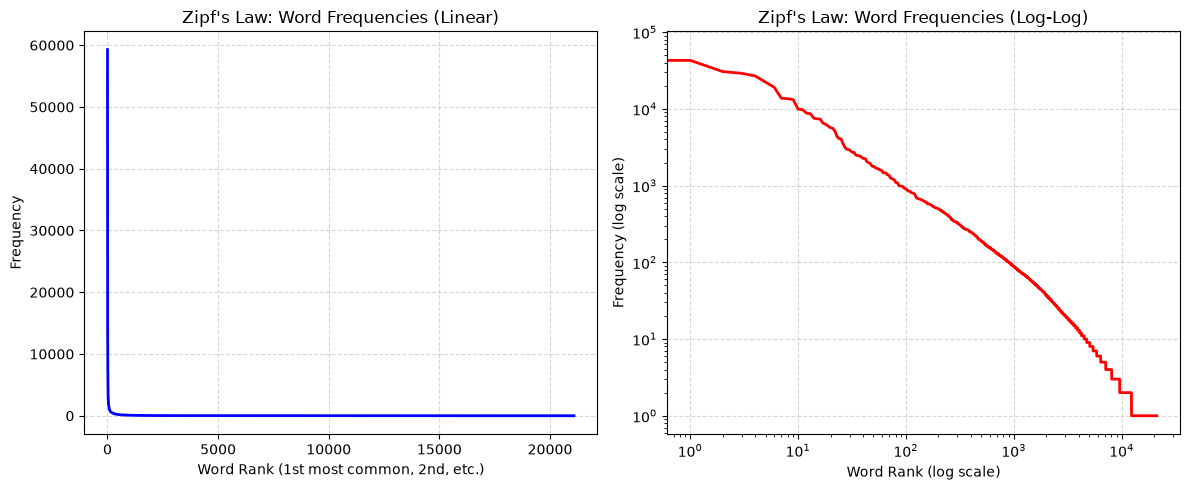

In [16]:
all_words = []
for s in sentences:
    words = re.sub(r"([?.!,¿])", r" \1 ", s.lower())
    words = re.sub(r" +", " ", words).strip().split()
    all_words.extend(words)

word_counts = Counter(all_words)
frequencies = sorted(list(word_counts.values()), reverse=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(frequencies, color='blue', linewidth=2)
plt.title("Zipf's Law: Word Frequencies (Linear)")
plt.xlabel("Word Rank (1st most common, 2nd, etc.)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(frequencies, color='red', linewidth=2)
plt.title("Zipf's Law: Word Frequencies (Log-Log)")
plt.xlabel("Word Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.xscale('log')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

If we set our `min_freq` parameter in the `SemanticTokenizer` too high, we destroy majority of the data

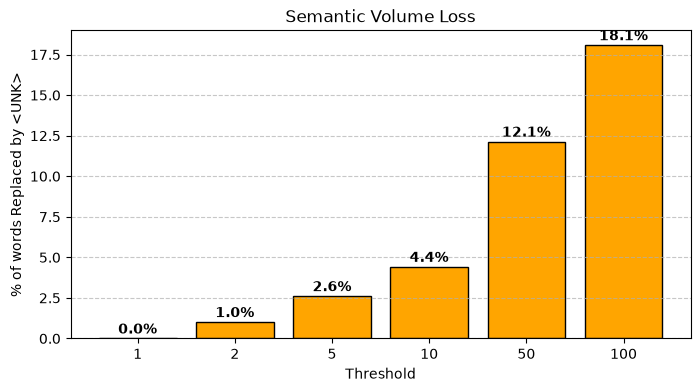

In [17]:
total_words = sum(frequencies)
thresholds = [1, 2, 5, 10, 50, 100]
unk_percentages = []

for t in thresholds:
    
    lost_words = sum(count for count in frequencies if count < t)
    unk_percentages.append((lost_words / total_words) * 100)

plt.figure(figsize=(8, 4))
bars = plt.bar([str(t) for t in thresholds], unk_percentages, color='orange', edgecolor='black')
plt.title("Semantic Volume Loss")
plt.xlabel("Threshold")
plt.ylabel("% of words Replaced by <UNK>")
plt.grid(axis='y', linestyle='--', alpha=0.7)


for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f"{bar.get_height():.1f}%", ha='center', va='bottom', fontweight='bold')

plt.show()



--- 
### Part 2: The Padding Tax (Bandwidth Waste)
Neural Networks (like our upcoming LSTM) process data in fixed-size square matrices. If we feed a batch of sentences, all short sentences must be filled with `<PAD>` tokens to match the longest sentence in the batch. 

In telecommunications, transmitting a `<PAD>` token through a physical channel consumes power and bandwidth for absolutely zero semantic gain. We call this the **Padding Tax**.

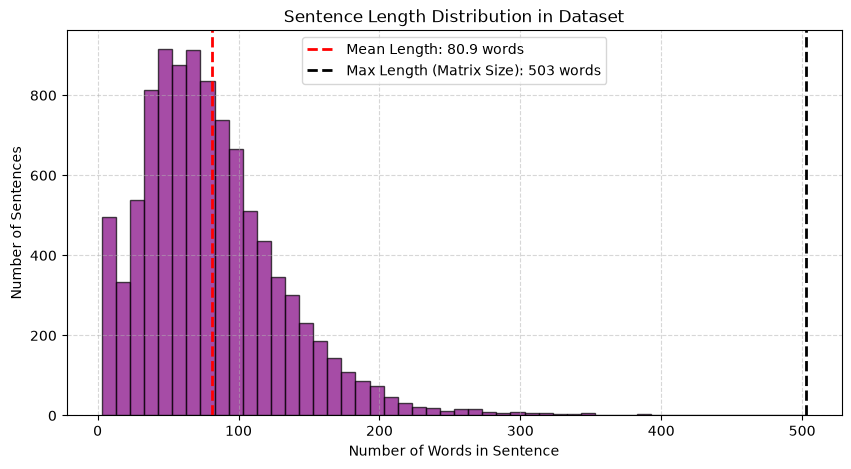

Total Grid Cells in Tensor: 4,913,807
Actual Semantic Words:      790,256
Empty <PAD> Tokens:         4,123,551

>>> BANDWIDTH WASTED (Padding Tax): 83.92% <<<


In [18]:
lengths = [len(s.split()) for s in sentences]
max_len_batch = max(lengths) if lengths else 0
mean_len = np.mean(lengths) if lengths else 0

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.title("Sentence Length Distribution in Dataset")
plt.xlabel("Number of Words in Sentence")
plt.ylabel("Number of Sentences")
plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean Length: {mean_len:.1f} words')
plt.axvline(max_len_batch, color='black', linestyle='dashed', linewidth=2, label=f'Max Length (Matrix Size): {max_len_batch} words')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


total_tokens_needed = len(sentences) * max_len_batch
actual_tokens = sum(lengths)
padding_tax = total_tokens_needed - actual_tokens
waste_percentage = (padding_tax / total_tokens_needed) * 100


print(f"Total Grid Cells in Tensor: {total_tokens_needed:,}")
print(f"Actual Semantic Words:      {actual_tokens:,}")
print(f"Empty <PAD> Tokens:         {padding_tax:,}")
print(f"\n>>> BANDWIDTH WASTED (Padding Tax): {waste_percentage:.2f}% <<<")

---
### Part 3: Shannon Entropy of the Vocabulary
Claude Shannon proved that the absolute minimum number of bits required to transmit a symbol is determined by its entropy ($H = -\sum P(x) \log_2 P(x)$).

Let's calculate the theoretical mathematical limit for transmitting a word from our dataset using standard 5G binary transmission.

In [19]:
entropy = 0
for count in frequencies:
    p_x = count / total_words
    entropy -= p_x * math.log2(p_x)

print(f"Shannon Entropy of our Word-Level Vocabulary: {entropy:.2f} bits per word")


Shannon Entropy of our Word-Level Vocabulary: 9.16 bits per word
